# 🏦 Loan Approval Prediction — Improved Pipeline
### Upgrades: Feature Engineering · Scaling · CV · Tuning · Pipeline · Save Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)

print('All libraries loaded ✅')

All libraries loaded ✅


## 1. Load & Explore Data

In [2]:
df = pd.read_csv('LoanApprovalPrediction.csv')
print('Shape:', df.shape)
df.head()

Shape: (598, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print('Target distribution:')
print(df['Loan_Status'].value_counts())
print(df['Loan_Status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Target distribution:
Loan_Status
Y    411
N    187
Name: count, dtype: int64
Loan_Status
Y    68.7%
N    31.3%
Name: proportion, dtype: object


In [4]:
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values:
Dependents          12
LoanAmount          21
Loan_Amount_Term    14
Credit_History      49
dtype: int64


## 2. Preprocessing

In [5]:
df.drop(['Loan_ID'], axis=1, inplace=True)

# Imputation
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    df[col].fillna(df[col].mode()[0], inplace=True)
for col in ['LoanAmount', 'Loan_Amount_Term']:
    df[col].fillna(df[col].median(), inplace=True)

# Fix Dependents '3+' -> 3
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

print('Missing after imputation:', df.isnull().sum().sum())

Missing after imputation: 0


## 3. 🚀 Feature Engineering

In [6]:
df['TotalIncome']        = df['ApplicantIncome'] + df['CoapplicantIncome']
df['EMI']                = df['LoanAmount'] / df['Loan_Amount_Term']
df['IncomeToLoanRatio']  = df['TotalIncome'] / (df['LoanAmount'] + 1)
df['RemainingIncome']    = df['TotalIncome'] - (df['EMI'] * 1000)
df['LoanAmount_log']     = np.log1p(df['LoanAmount'])
df['TotalIncome_log']    = np.log1p(df['TotalIncome'])
df['ApplicantIncome_log']= np.log1p(df['ApplicantIncome'])

print('New features added. Total columns:', df.shape[1])
df[['TotalIncome','EMI','IncomeToLoanRatio','RemainingIncome']].describe()

New features added. Total columns: 19


,TotalIncome,EMI,IncomeToLoanRatio,RemainingIncome
count,598.000000,598.000000,598.000000,598.000000
mean,6923.752375,0.469980,50.627548,6453.772382
std,6220.893093,0.510840,37.077602,6067.186422
min,1442.000000,0.025000,12.042969,-1768.000000
25%,4154.750000,0.286806,35.197414,3780.555556
50%,5416.500000,0.358333,41.221917,4979.333333
75%,7452.500000,0.504861,51.598930,6865.888889
max,81000.000000,9.250000,392.010989,80000.000000


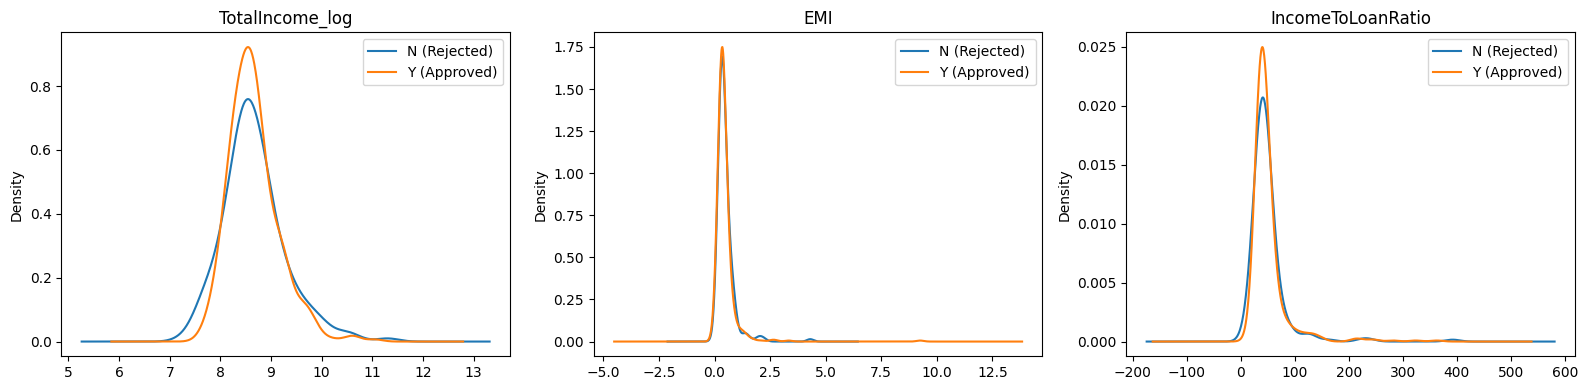

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['TotalIncome_log', 'EMI', 'IncomeToLoanRatio']):
    df.groupby('Loan_Status')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
    ax.legend(['N (Rejected)', 'Y (Approved)'])
plt.tight_layout()
plt.show()

## 4. Encoding & Target

In [8]:
df['Loan_Status'] = df['Loan_Status'].map({'N': 0, 'Y': 1})
categorical_cols  = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df['Credit_History']   = df['Credit_History'].astype(int)
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].astype(int)

print('Final shape:', df.shape)
print('Columns:', list(df.columns))

Final shape: (598, 20)
Columns: ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'TotalIncome', 'EMI', 'IncomeToLoanRatio', 'RemainingIncome', 'LoanAmount_log', 'TotalIncome_log', 'ApplicantIncome_log', 'Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']


## 5. Correlation Heatmap

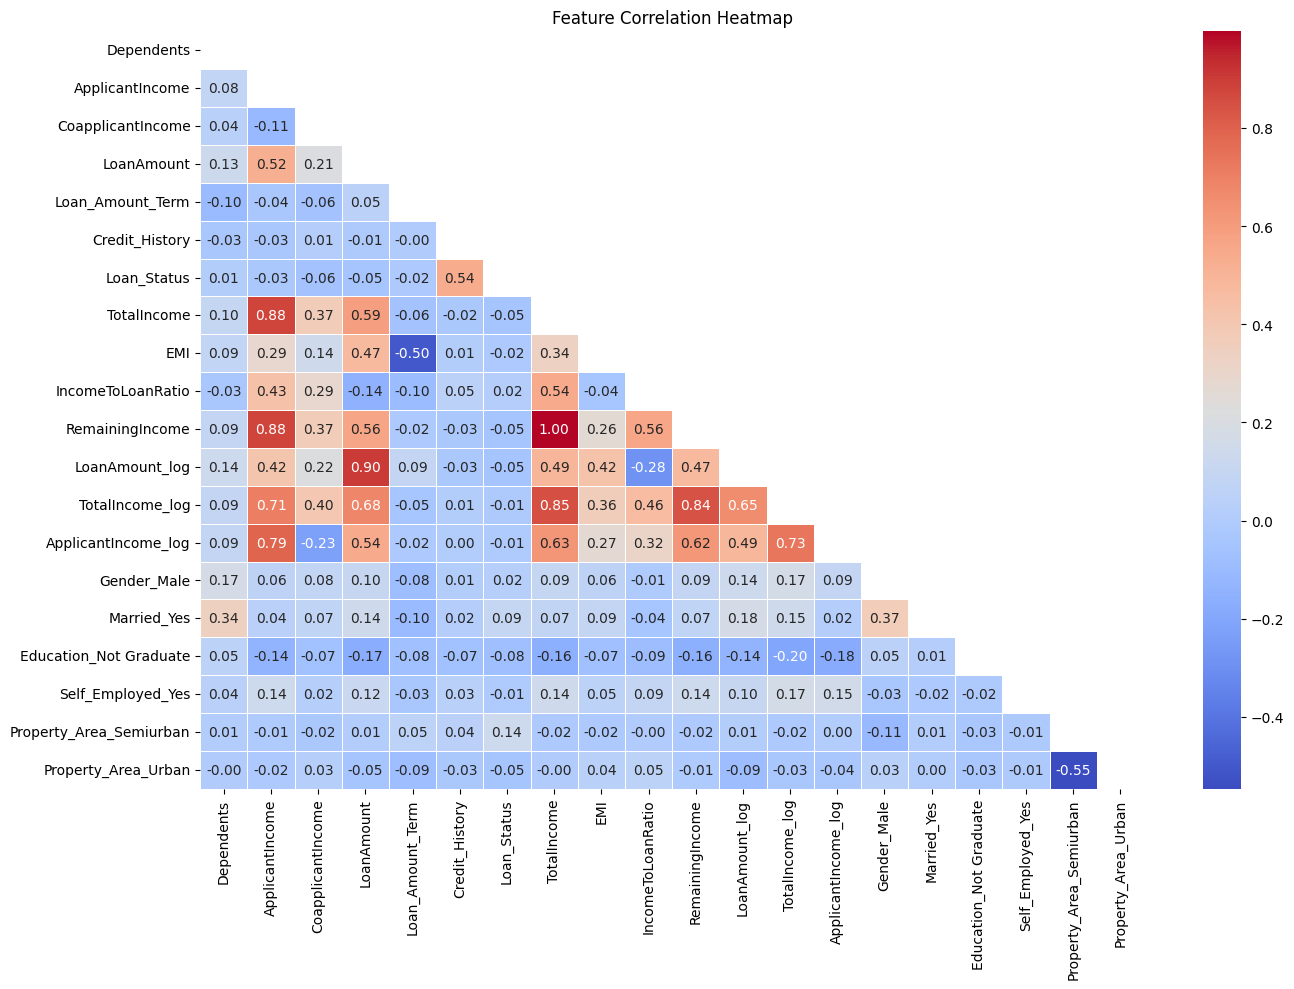

In [9]:
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 6. Train-Test Split

In [10]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# 80/20 stratified split
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {Xtrain.shape}, Test: {Xtest.shape}')
print(f'Train class balance: {ytrain.value_counts().to_dict()}')
print(f'Test  class balance: {ytest.value_counts().to_dict()}')

Train: (478, 19), Test: (120, 19)
Train class balance: {1: 329, 0: 149}
Test  class balance: {1: 82, 0: 38}


## 7. Evaluation Helper

In [11]:
results = {}

def evaluate(name, pipeline, Xtr, Xte, ytr, yte):
    pipeline.fit(Xtr, ytr)
    train_acc  = pipeline.score(Xtr, ytr)
    test_acc   = pipeline.score(Xte, yte)
    ytest_pred = pipeline.predict(Xte)
    ytest_prob = pipeline.predict_proba(Xte)[:, 1]
    auc        = roc_auc_score(yte, ytest_prob)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, Xtr, ytr, cv=cv, scoring='accuracy')

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Train Accuracy : {train_acc:.4f}')
    print(f'  Test  Accuracy : {test_acc:.4f}')
    print(f'  ROC-AUC        : {auc:.4f}')
    print(f'  CV (5-fold)    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'\nClassification Report (Test):')
    print(classification_report(yte, ytest_pred))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(yte, ytest_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'{name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(yte, ytest_prob)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    axes[1].plot([0,1],[0,1],'k--')
    axes[1].set_title(f'{name} — ROC Curve')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    results[name] = {
        'Train Acc': round(train_acc, 4),
        'Test Acc':  round(test_acc, 4),
        'ROC-AUC':   round(auc, 4),
        'CV Mean':   round(cv_scores.mean(), 4),
        'CV Std':    round(cv_scores.std(), 4)
    }
    return pipeline

print('Helper defined ✅')

Helper defined ✅


## 8. Logistic Regression


  Logistic Regression
  Train Accuracy : 0.7845
  Test  Accuracy : 0.7917
  ROC-AUC        : 0.8245
  CV (5-fold)    : 0.7344 ± 0.0609

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.70      0.61      0.65        38
           1       0.83      0.88      0.85        82

    accuracy                           0.79       120
   macro avg       0.76      0.74      0.75       120
weighted avg       0.79      0.79      0.79       120



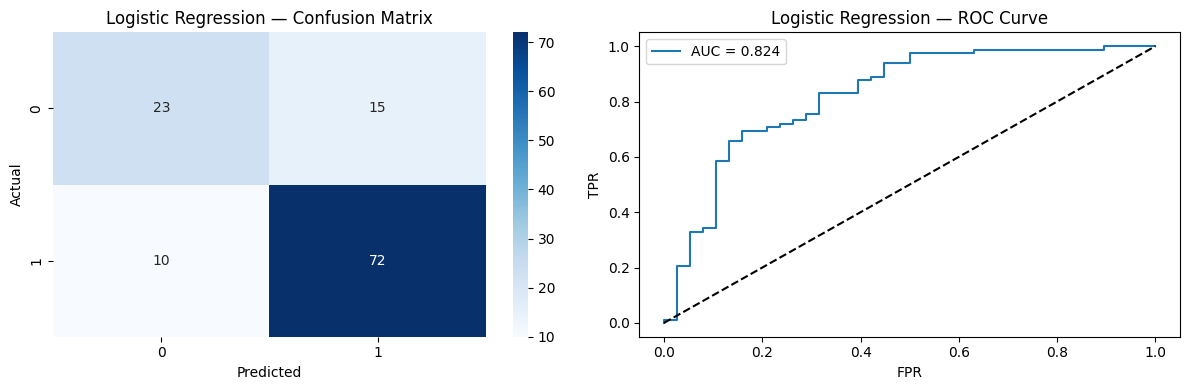

In [12]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, class_weight='balanced', max_iter=10000, random_state=42))
])
lr_pipe = evaluate('Logistic Regression', lr_pipe, Xtrain, Xtest, ytrain, ytest)

## 9. Random Forest


  Random Forest
  Train Accuracy : 0.8745
  Test  Accuracy : 0.7917
  ROC-AUC        : 0.7962
  CV (5-fold)    : 0.7971 ± 0.0425

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.78      0.47      0.59        38
           1       0.79      0.94      0.86        82

    accuracy                           0.79       120
   macro avg       0.79      0.71      0.73       120
weighted avg       0.79      0.79      0.77       120



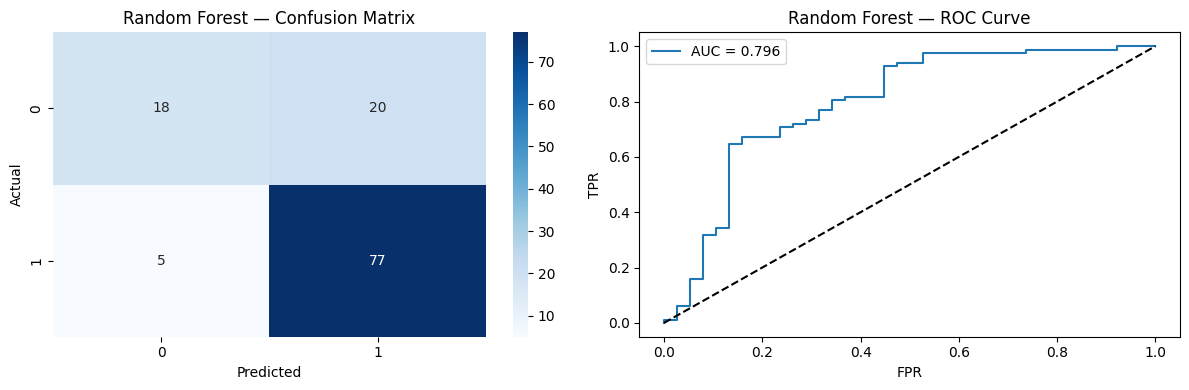

In [13]:
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=2,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])
rf_pipe = evaluate('Random Forest', rf_pipe, Xtrain, Xtest, ytrain, ytest)

## 10. KNN


  KNN
  Train Accuracy : 1.0000
  Test  Accuracy : 0.7833
  ROC-AUC        : 0.7423
  CV (5-fold)    : 0.7718 ± 0.0421

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.80      0.42      0.55        38
           1       0.78      0.95      0.86        82

    accuracy                           0.78       120
   macro avg       0.79      0.69      0.70       120
weighted avg       0.79      0.78      0.76       120



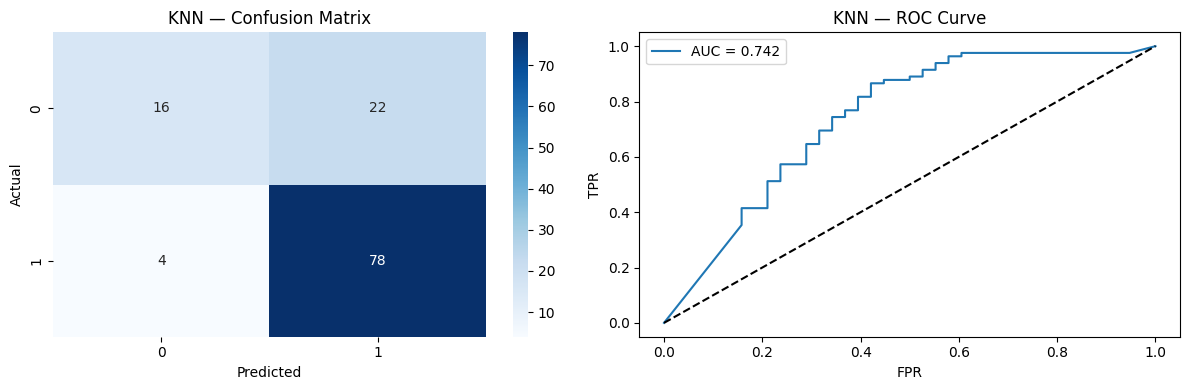

In [14]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=7, weights='distance'))
])
knn_pipe = evaluate('KNN', knn_pipe, Xtrain, Xtest, ytrain, ytest)

## 11. Gradient Boosting


  Gradient Boosting
  Train Accuracy : 0.9623
  Test  Accuracy : 0.8083
  ROC-AUC        : 0.7940
  CV (5-fold)    : 0.7678 ± 0.0465

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.83      0.50      0.62        38
           1       0.80      0.95      0.87        82

    accuracy                           0.81       120
   macro avg       0.82      0.73      0.75       120
weighted avg       0.81      0.81      0.79       120



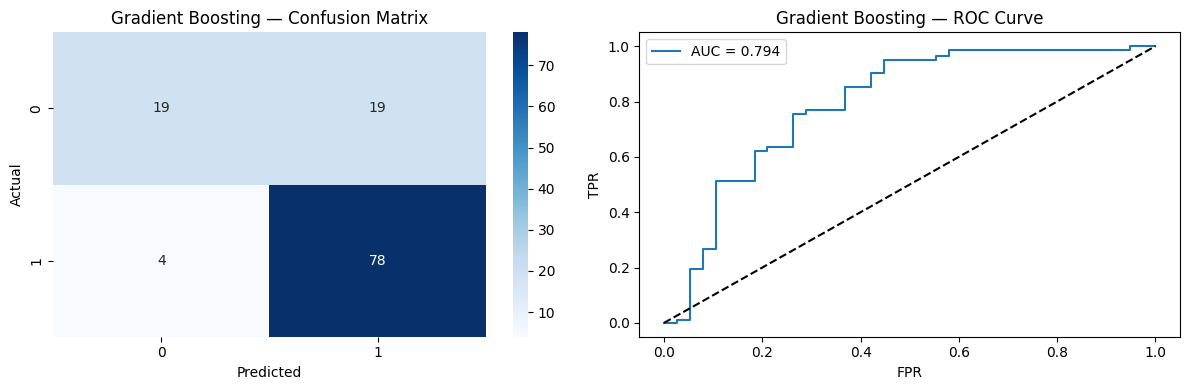

In [15]:
gb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=3, subsample=0.8,
        min_samples_leaf=5, random_state=42
    ))
])
gb_pipe = evaluate('Gradient Boosting', gb_pipe, Xtrain, Xtest, ytrain, ytest)

## 12. 🔧 Hyperparameter Tuning (Pipeline-based — fixes scaler mismatch!)

In [16]:
# Using Pipeline inside GridSearchCV ensures scaler is always fit correctly
tune_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

param_grid = {
    'clf__n_estimators':   [200, 300, 400],
    'clf__max_depth':      [4, 5, 6, 7],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features':   ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    tune_pipe, param_grid,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(Xtrain, ytrain)

print('Best params:', grid_search.best_params_)
print('Best CV AUC:', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'clf__max_depth': 7, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 400}
Best CV AUC: 0.7384



  Random Forest (Tuned)
  Train Accuracy : 0.8975
  Test  Accuracy : 0.8083
  ROC-AUC        : 0.7875
  CV (5-fold)    : 0.7929 ± 0.0368

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.83      0.50      0.62        38
           1       0.80      0.95      0.87        82

    accuracy                           0.81       120
   macro avg       0.82      0.73      0.75       120
weighted avg       0.81      0.81      0.79       120



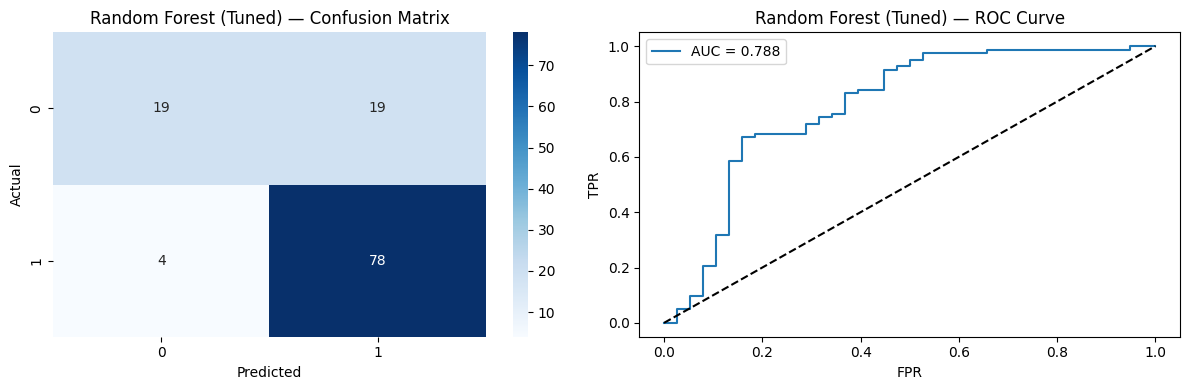

In [17]:
best_model = evaluate('Random Forest (Tuned)', grid_search.best_estimator_, Xtrain, Xtest, ytrain, ytest)

## 13. 🗳️ Voting Ensemble


  Voting Ensemble
  Train Accuracy : 0.9770
  Test  Accuracy : 0.8083
  ROC-AUC        : 0.8097
  CV (5-fold)    : 0.7909 ± 0.0478

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.83      0.50      0.62        38
           1       0.80      0.95      0.87        82

    accuracy                           0.81       120
   macro avg       0.82      0.73      0.75       120
weighted avg       0.81      0.81      0.79       120



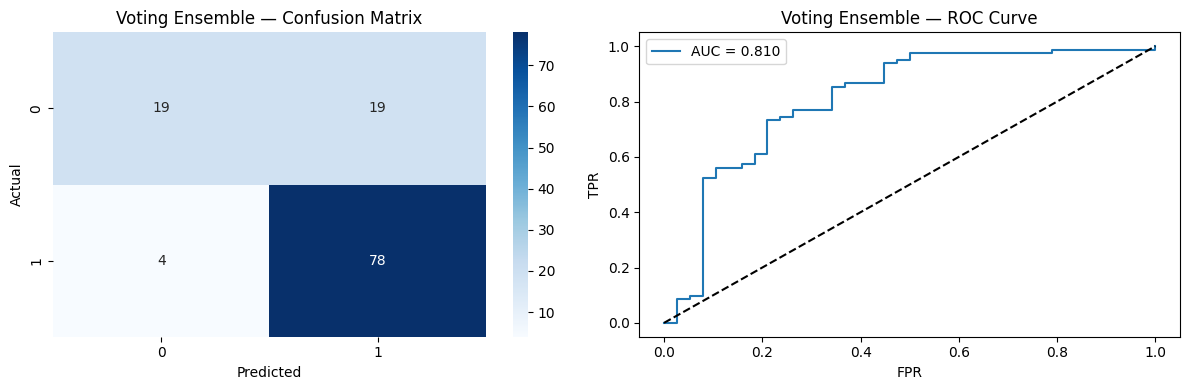

In [18]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr',  lr_pipe),
        ('rf',  grid_search.best_estimator_),
        ('gb',  gb_pipe),
        ('knn', knn_pipe)
    ],
    voting='soft',
    weights=[1, 2, 2, 1]
)
voting_clf = evaluate('Voting Ensemble', voting_clf, Xtrain, Xtest, ytrain, ytest)

## 14. 📊 Feature Importance

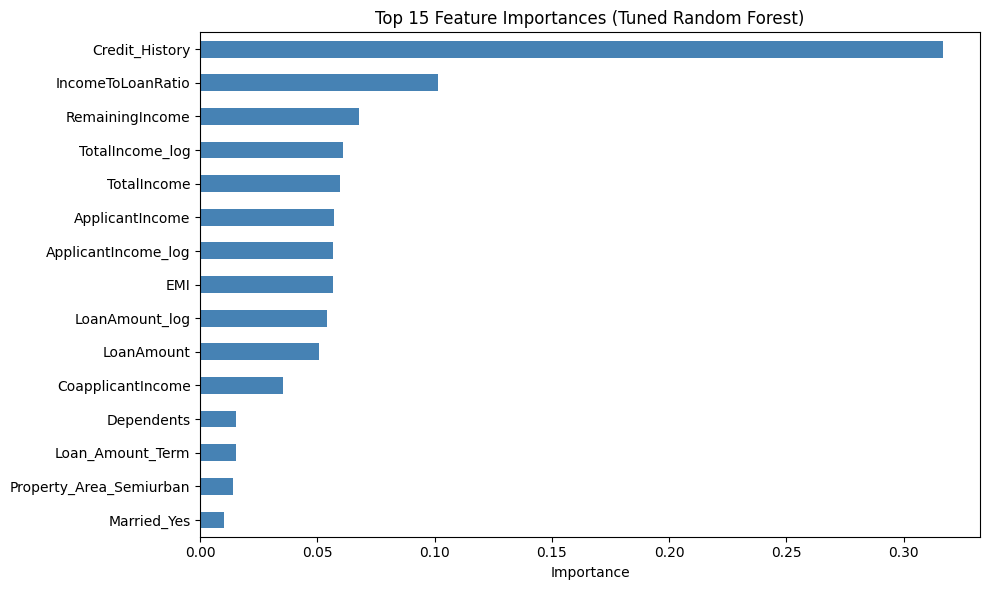

Credit_History             0.316691
IncomeToLoanRatio          0.101591
RemainingIncome            0.067497
TotalIncome_log            0.060706
TotalIncome                0.059694
ApplicantIncome            0.056887
ApplicantIncome_log        0.056830
EMI                        0.056549
LoanAmount_log             0.054154
LoanAmount                 0.050820
CoapplicantIncome          0.035144
Dependents                 0.015209
Loan_Amount_Term           0.015108
Property_Area_Semiurban    0.014153
Married_Yes                0.010131
dtype: float64


In [19]:
feat_imp = pd.Series(
    grid_search.best_estimator_.named_steps['clf'].feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (Tuned Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(feat_imp)

## 15. 📈 Model Comparison

                       Train Acc  Test Acc  ROC-AUC  CV Mean  CV Std
Random Forest (Tuned)     0.8975    0.8083   0.7875   0.7929  0.0368
Gradient Boosting         0.9623    0.8083   0.7940   0.7678  0.0465
Voting Ensemble           0.9770    0.8083   0.8097   0.7909  0.0478
Logistic Regression       0.7845    0.7917   0.8245   0.7344  0.0609
Random Forest             0.8745    0.7917   0.7962   0.7971  0.0425
KNN                       1.0000    0.7833   0.7423   0.7718  0.0421


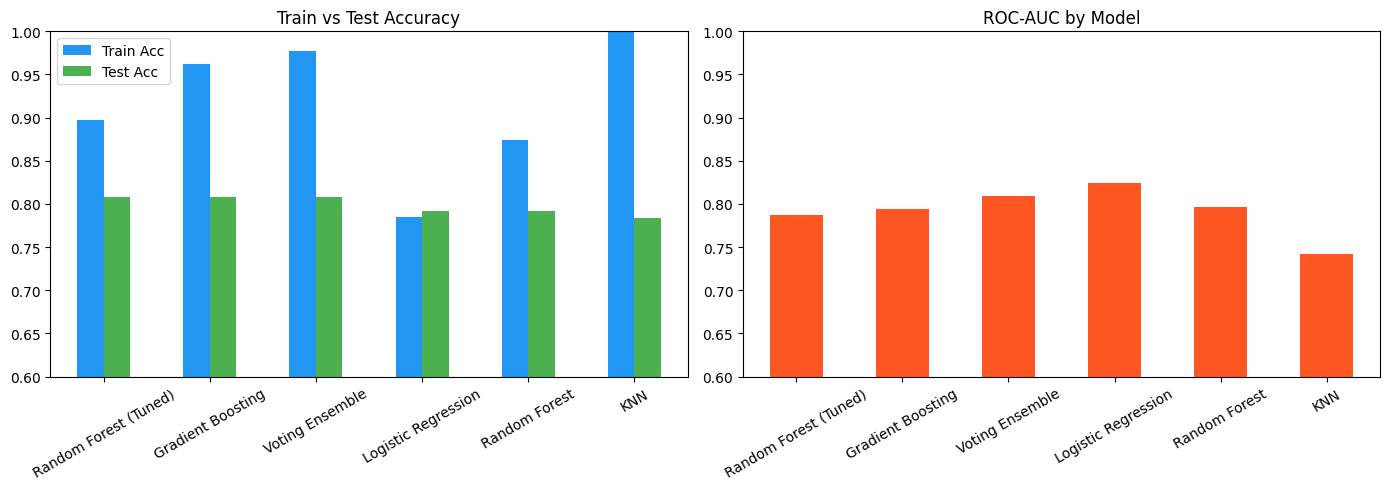

In [20]:
results_df = pd.DataFrame(results).T.sort_values('Test Acc', ascending=False)
print(results_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df[['Train Acc', 'Test Acc']].plot(kind='bar', ax=axes[0], color=['#2196F3','#4CAF50'])
axes[0].set_title('Train vs Test Accuracy')
axes[0].set_ylim(0.6, 1.0)
axes[0].tick_params(axis='x', rotation=30)

results_df['ROC-AUC'].plot(kind='bar', ax=axes[1], color='#FF5722')
axes[1].set_title('ROC-AUC by Model')
axes[1].set_ylim(0.6, 1.0)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 16. 💾 Save Model & Columns for Flask Deployment

In [21]:
# Save the best pipeline (scaler + model inside — no separate scaler needed!)
pickle.dump(grid_search.best_estimator_, open('model.pkl', 'wb'))

# Save column order — CRITICAL to avoid feature mismatch in Flask
pickle.dump(list(X.columns), open('columns.pkl', 'wb'))

print('✅ model.pkl saved!   (Pipeline: scaler + RandomForest)')
print('✅ columns.pkl saved!')
print('\nColumn order:')
for i, col in enumerate(X.columns):
    print(f'  {i}: {col}')

✅ model.pkl saved!   (Pipeline: scaler + RandomForest)
✅ columns.pkl saved!

Column order:
  0: Dependents
  1: ApplicantIncome
  2: CoapplicantIncome
  3: LoanAmount
  4: Loan_Amount_Term
  5: Credit_History
  6: TotalIncome
  7: EMI
  8: IncomeToLoanRatio
  9: RemainingIncome
  10: LoanAmount_log
  11: TotalIncome_log
  12: ApplicantIncome_log
  13: Gender_Male
  14: Married_Yes
  15: Education_Not Graduate
  16: Self_Employed_Yes
  17: Property_Area_Semiurban
  18: Property_Area_Urban


## 17. ✅ Verify Saved Model

In [23]:
loaded_model   = pickle.load(open('model.pkl', 'rb'))
loaded_columns = pickle.load(open('columns.pkl', 'rb'))

# Build a strong applicant sample
sample = pd.DataFrame(0, index=[0], columns=loaded_columns)
sample['Dependents']          = 0
sample['ApplicantIncome']     = 8000
sample['CoapplicantIncome']   = 3000
sample['LoanAmount']          = 150
sample['Loan_Amount_Term']    = 360
sample['Credit_History']      = 1
sample['TotalIncome']         = 11000
sample['EMI']                 = 150/360
sample['IncomeToLoanRatio']   = 11000/151
sample['RemainingIncome']     = 11000 - (150/360)*1000
sample['LoanAmount_log']      = np.log1p(150)
sample['TotalIncome_log']     = np.log1p(11000)
sample['ApplicantIncome_log'] = np.log1p(8000)

# Set one-hot columns if they exist in YOUR dataset
for col in ['Gender_Male', 'Married_Yes', 'Property_Area_Semiurban']:
    if col in sample.columns:
        sample[col] = 1

pred = loaded_model.predict(sample)
prob = loaded_model.predict_proba(sample)[0][1]

print('Prediction :', 'Approved ✅' if pred[0]==1 else 'Rejected ❌')
print(f'Probability: {prob*100:.1f}%')
print('\n✅ Model is ready!')

Prediction : Approved ✅
Probability: 67.1%

✅ Model is ready!


## ✅ Summary of Improvements

| What changed | Old | New |
|---|---|---|
| Train/Test split | 60/40 | **80/20 + stratified** |
| Feature scaling | ❌ None | **✅ Inside Pipeline (no mismatch)** |
| Feature engineering | ❌ None | **✅ TotalIncome, EMI, Ratios, Log transforms** |
| Evaluation | Single split | **✅ 5-fold CV + ROC-AUC** |
| Hyperparameter tuning | Manual | **✅ GridSearchCV inside Pipeline** |
| Model combination | Single models | **✅ Soft Voting Ensemble** |
| KNN | Unscaled ⚠️ | **✅ Scaled inside Pipeline** |
| Save model | ❌ Not saved | **✅ model.pkl + columns.pkl** |